In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder 

In [54]:
df = pd.read_csv("./WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 1. Understanding the dataset

In [55]:
df.shape

(7043, 21)

In [56]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [57]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [59]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


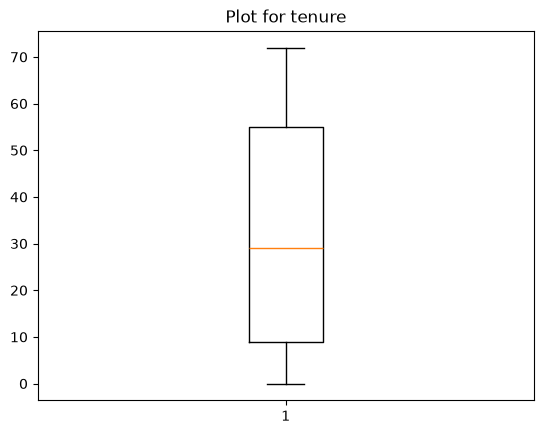

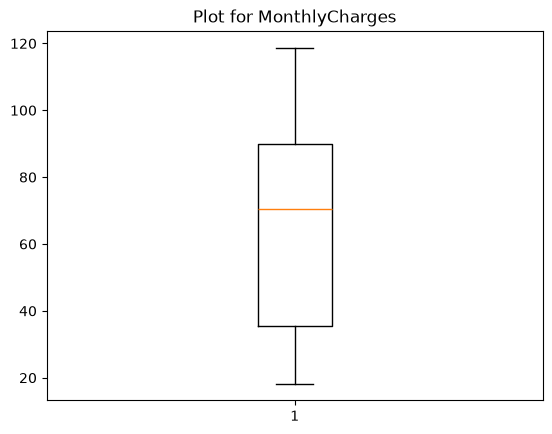

In [62]:
num_col = ["tenure", "MonthlyCharges"]

for col in num_col:
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

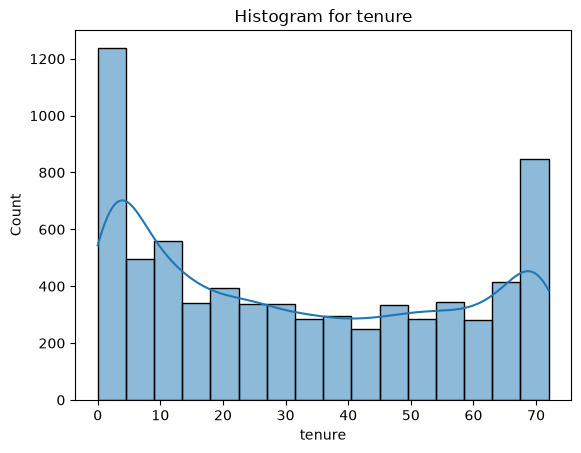

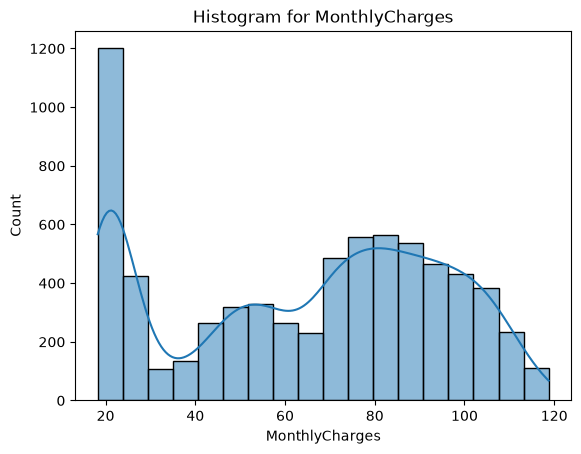

In [63]:
for col in num_col:
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram for {col}")
    plt.show()

## 2. Pre processing the data for training model

In [64]:
dfcopy = df.copy()

dfcopy.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [65]:
dfcopy = dfcopy.drop("customerID", axis=1)


dfcopy.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [95]:
dfcopy["TotalCharges"] = pd.to_numeric(dfcopy["TotalCharges"], errors="coerce")

In [98]:
dfcopy[dfcopy["TotalCharges"].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
488,0,0,1,1,0,0,1,52.55,NaN,0,...,True,False,True,False,False,False,True,False,False,False
753,1,0,0,1,0,1,0,20.25,NaN,0,...,False,True,False,True,False,False,True,False,False,True
936,0,0,1,1,0,1,0,80.85,NaN,0,...,False,False,True,False,True,False,True,False,False,True
1082,1,0,1,1,0,1,0,25.75,NaN,0,...,False,True,False,True,False,False,True,False,False,True
1340,0,0,1,1,0,0,0,56.05,NaN,0,...,True,False,True,False,False,False,True,True,False,False
3331,1,0,1,1,0,1,0,19.85,NaN,0,...,False,True,False,True,False,False,True,False,False,True
3826,1,0,1,1,0,1,0,25.35,NaN,0,...,False,True,False,True,False,False,True,False,False,True
4380,0,0,1,1,0,1,0,20.00,NaN,0,...,False,True,False,True,False,False,True,False,False,True
5218,1,0,1,1,0,1,1,19.70,NaN,0,...,False,True,False,True,False,True,False,False,False,True
6670,0,0,1,1,0,1,0,73.35,NaN,0,...,True,False,True,False,False,False,True,False,False,True


In [99]:
dfcopy = dfcopy.dropna(subset=["TotalCharges"])

In [100]:
dfcopy["TotalCharges"].info()

<class 'pandas.Series'>
Index: 7032 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7032 non-null   float64
dtypes: float64(1)
memory usage: 109.9 KB


### Label Encoding the categorical columns

In [66]:
dfcopy["gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [67]:
le = LabelEncoder()

dfcopy["gender"] = le.fit_transform(dfcopy["gender"])

dfcopy["gender"].unique()

array([0, 1])

In [68]:
dfcopy["Partner"] = le.fit_transform(dfcopy["Partner"])

dfcopy["Partner"].unique()

array([1, 0])

In [69]:
dfcopy["Dependents"] = le.fit_transform(dfcopy["Dependents"])

dfcopy["Dependents"].unique()

array([0, 1])

In [70]:
dfcopy["PhoneService"] = le.fit_transform(dfcopy["PhoneService"])

dfcopy["PhoneService"].unique()

array([0, 1])

In [85]:
dfcopy["PaperlessBilling"] = le.fit_transform(dfcopy["PaperlessBilling"])

dfcopy["PaperlessBilling"].unique()

array([1, 0])

In [90]:
dfcopy["Churn"] = le.fit_transform(dfcopy["Churn"])

dfcopy["Churn"].unique()

array([0, 1])

### One Hot encoding categorical columns

In [71]:
dfcopy["MultipleLines"].unique()

<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

In [72]:
dfcopy = pd.get_dummies(dfcopy, columns=["MultipleLines"], drop_first=True)

dfcopy.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes
0,0,0,1,0,1,0,DSL,No,Yes,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,True,False
1,1,0,0,0,34,1,DSL,Yes,No,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,False,False
2,1,0,0,0,2,1,DSL,Yes,Yes,No,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,False,False
3,1,0,0,0,45,0,DSL,Yes,No,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,True,False
4,0,0,0,0,2,1,Fiber optic,No,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,False,False


In [74]:
dfcopy = pd.get_dummies(dfcopy, columns=["InternetService"], drop_first=True)

dfcopy.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,No,Yes,No,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,True,False,False,False
1,1,0,0,0,34,1,Yes,No,Yes,No,...,One year,No,Mailed check,56.95,1889.5,No,False,False,False,False
2,1,0,0,0,2,1,Yes,Yes,No,No,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,False,False,False,False
3,1,0,0,0,45,0,Yes,No,Yes,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,True,False,False,False
4,0,0,0,0,2,1,No,No,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,False,False,True,False


In [ ]:
dfcopy = pd.get_dummies(dfcopy, columns=["OnlineSecurity"], drop_first=True)

dfcopy.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes
0,0,0,1,0,1,0,Yes,No,No,No,...,Electronic check,29.85,29.85,No,True,False,False,False,False,False
1,1,0,0,0,34,1,No,Yes,No,No,...,Mailed check,56.95,1889.5,No,False,False,False,False,False,True


In [80]:
dfcopy = pd.get_dummies(dfcopy, columns=["OnlineBackup"], drop_first=True)

dfcopy.head(2)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,...,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes
0,0,0,1,0,1,0,No,No,No,No,...,29.85,No,True,False,False,False,False,False,False,True
1,1,0,0,0,34,1,Yes,No,No,No,...,1889.5,No,False,False,False,False,False,True,False,False


In [83]:
onehot_col = ["DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]


for col in onehot_col:
    dfcopy = pd.get_dummies(dfcopy, columns=[col], drop_first=True)

dfcopy.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,Month-to-month,Yes,Electronic check,29.85,...,False,True,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,One year,No,Mailed check,56.95,...,False,False,False,True,False,False,False,False,False,False


In [88]:
dfcopy = pd.get_dummies(dfcopy, columns=["Contract", "PaymentMethod"], drop_first=True)

dfcopy.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,No,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.5,No,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,Yes,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,No,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,Yes,...,False,False,False,False,False,False,False,False,True,False


## 3. Preparing the model

In [ ]:
X = dfcopy.drop("Churn", axis=1)
y = dfcopy["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

Model Trianed


C:\Users\tusha\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. Checking the parameters of the model

Accuracy:  0.7867803837953091

 Confusion Matrix: 
 [[914 119]
 [181 193]]

 Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Roc AUC score:  0.8320710665679631


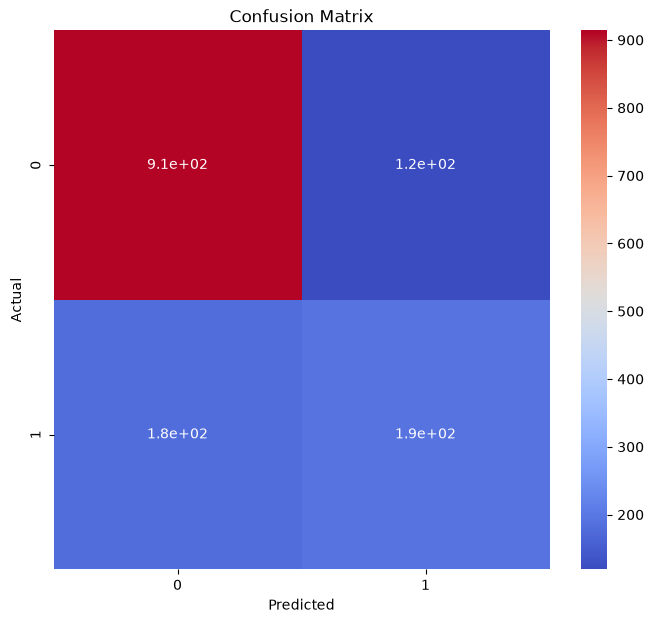

In [103]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

print("Accuracy: ", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix: \n", cm)

print("\n Classification Report: \n", classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("Roc AUC score: ", roc_auc)

plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, cmap="coolwarm")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 5. Inference form the model

In [105]:
new_customer = pd.DataFrame({
    'gender': [1],
    'SeniorCitizen': [0],
    'Partner': [0],
    'Dependents': [0],
    'tenure': [3],
    'PhoneService': [1],
    'PaperlessBilling': [1],
    'MonthlyCharges': [89.50],
    'TotalCharges': [268.50],

    'MultipleLines_No phone service': [0],
    'MultipleLines_Yes': [1],

    'InternetService_Fiber optic': [1],
    'InternetService_No': [0],

    'OnlineSecurity_No internet service': [0],
    'OnlineSecurity_Yes': [0],

    'OnlineBackup_No internet service': [0],
    'OnlineBackup_Yes': [0],

    'DeviceProtection_No internet service': [0],
    'DeviceProtection_Yes': [0],

    'TechSupport_No internet service': [0],
    'TechSupport_Yes': [0],

    'StreamingTV_No internet service': [0],
    'StreamingTV_Yes': [1],

    'StreamingMovies_No internet service': [0],
    'StreamingMovies_Yes': [1],

    'Contract_One year': [0],
    'Contract_Two year': [0],

    'PaymentMethod_Credit card (automatic)': [0],
    'PaymentMethod_Electronic check': [1],
    'PaymentMethod_Mailed check': [0]
})

probability = model.predict_proba(new_customer)[:, 1][0]
prediction = model.predict(new_customer)[0]

print("Predicted Probability of Churn:", round(probability, 2))
print("Predicted Class (0 = No Churn, 1 = Churn):", prediction)

Predicted Probability of Churn: 0.8
Predicted Class (0 = No Churn, 1 = Churn): 1
